In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [2]:
path = "/kaggle/input/datasets/arunbailwal/beefcattlemuzzle/BeefCattle_Muzzle_Individualized"

**Exploratory Data Analysis**

*Create a Dataframe for cattle images*

In [3]:
data = {'Cattle_id': [], 'Path': [], 'No_of_images': []}

folder = path

df = pd.DataFrame(data)
folder = path
for label in os.listdir(folder):
    label_folder = os.path.join(folder, label)
    data['Cattle_id'].append(label)
    data['Path'].append(label_folder)
    count = 0
    if os.path.isdir(label_folder):
        for filename in os.listdir(label_folder):
            if filename.endswith('.jpg'):
                count+=1
    data['No_of_images'].append(count)

df = pd.DataFrame(data)
df.head()
    
    

,Cattle_id,Path,No_of_images
0,cattle_5153,/kaggle/input/datasets/arunbailwal/beefcattlem...,5
1,cattle_5886,/kaggle/input/datasets/arunbailwal/beefcattlem...,25
2,cattle_1900,/kaggle/input/datasets/arunbailwal/beefcattlem...,8
3,cattle_5519,/kaggle/input/datasets/arunbailwal/beefcattlem...,25
4,cattle_4947,/kaggle/input/datasets/arunbailwal/beefcattlem...,15


In [4]:
df.to_csv('Cattle_dataset.csv', index= True)

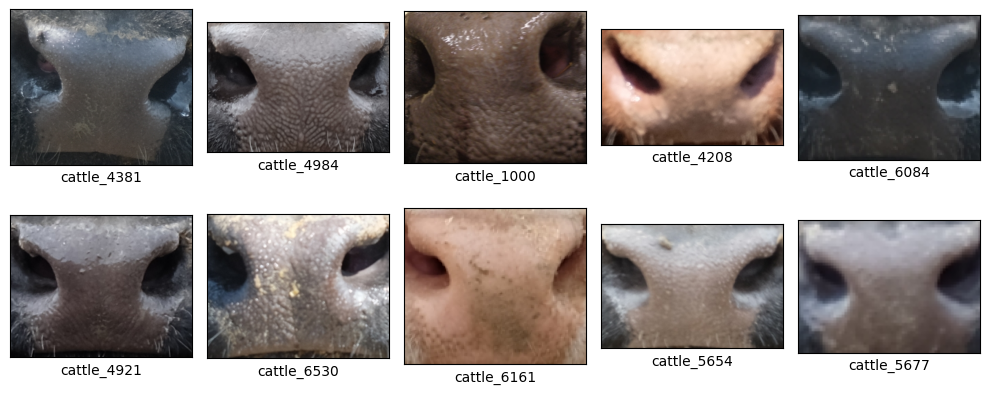

In [5]:


plt.figure(figsize=(10, 10))

for i in range(10):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    rand_index = np.random.randint(0, len(df))
    folder = df['Path'][rand_index]
    files = os.listdir(folder)   
    rand_file = np.random.choice(files)
    img_path = os.path.join(folder, rand_file)
    
    img = plt.imread(img_path)
    if img.max() > 1.0:
        img = img / 255.0
    plt.imshow(img)
    plt.xlabel(df['Cattle_id'][rand_index])  

plt.tight_layout()
plt.savefig('visualization.jpg', dpi=150)  
plt.show()
plt.close()


In [6]:
min_val = df['No_of_images'].min()
max_val = df['No_of_images'].max()   
max_val , min_val

(70, 4)

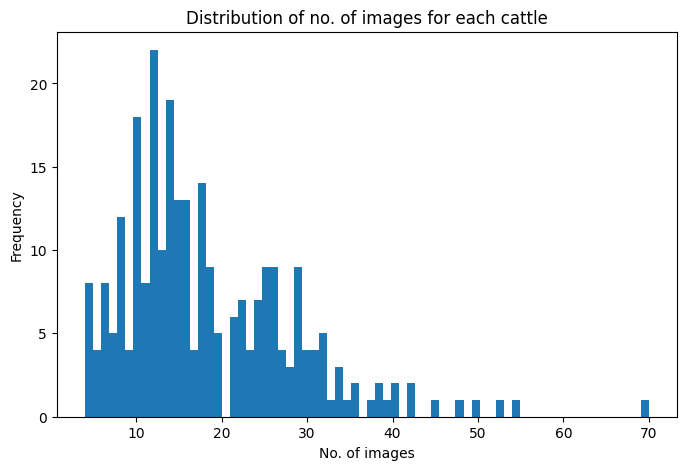

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['No_of_images'], bins = 70)
plt.xlabel('No. of images')
plt.ylabel('Frequency')
plt.title('Distribution of no. of images for each cattle')
plt.savefig('Distribution_of_no_of_images.jpg')
plt.show()

plt.close()

*Dividing dataset based on threshold 10 on no of images*

In [8]:

df_known = df.sample(frac=0.8, random_state=42)
df_unknown = df.drop(df_known.index)
df_known.to_csv('KnownDataset.csv', index = True)
df_unknown.to_csv('UnknownDataset.csv', index = True)

In [9]:
print(df_unknown.describe())
print(df_known.describe())

       No_of_images
count     54.000000
mean      17.888889
std        8.359080
min        4.000000
25%       12.000000
50%       15.500000
75%       23.750000
max       38.000000
       No_of_images
count    214.000000
mean      18.490654
std       10.586439
min        4.000000
25%       11.000000
50%       16.000000
75%       25.000000
max       70.000000


In [10]:
df_known.head(4)

,Cattle_id,Path,No_of_images
115,cattle_5427,/kaggle/input/datasets/arunbailwal/beefcattlem...,13
213,cattle_0100,/kaggle/input/datasets/arunbailwal/beefcattlem...,8
22,cattle_5697,/kaggle/input/datasets/arunbailwal/beefcattlem...,31
132,cattle_5762,/kaggle/input/datasets/arunbailwal/beefcattlem...,7


**Load Dataset**

In [11]:
import os
import cv2
import numpy as np

labels = []
images = []

for _, row in df_known.iterrows():
    for filename in os.listdir(row['Path']):
        img_path = os.path.join(row['Path'], filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (224, 224))
            images.append(img)
            labels.append(row['Cattle_id'])   
X = np.array(images, dtype=np.float32)  
print("Images:", X.shape)

Images: (3957, 224, 224, 3)


**One Hot Encoding**

In [12]:
from sklearn.preprocessing import LabelEncoder
processed = []
for i, lbl in enumerate(labels):
    arr = np.asarray(lbl)
    if arr.ndim == 0:
        processed.append(str(lbl))
    elif arr.ndim == 1 and arr.size > 1:

        idx = int(np.argmax(arr))
        processed.append(str(idx))
    else:
        processed.append(str(lbl))
processed = np.array(processed)
encoder = LabelEncoder()
int_labels = encoder.fit_transform(processed)

y = int_labels
num_classes = len(np.unique(int_labels))

In [13]:
y = np.array(y).astype(np.int64)
print('y shape:', y.shape)
print('y dtype:', y.dtype)
print('unique labels count:', len(np.unique(y)))
print('sample labels:', np.unique(y)[:10])

y shape: (3957,)
y dtype: int64
unique labels count: 214
sample labels: [0 1 2 3 4 5 6 7 8 9]


**"Dataset split into train , validation and test**

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
print("Type X:", type(X), "Type y:", type(y))
len_X = len(X)
y = np.asarray(y)
len_y = len(y)
print("len(X) =", len_X, "len(y) =", len_y)
if len_X != len_y:
    raise ValueError("len(X) and len(y) must match. Fix your inputs before splitting.")

min_samples_per_class = 1 
label_counts = Counter(y)
valid_classes = [lab for lab, cnt in label_counts.items() if cnt >= min_samples_per_class]
print("Total classes:", len(label_counts), "Kept classes (>=%d samples):" % min_samples_per_class, len(valid_classes))

mask = np.isin(y, valid_classes)
if isinstance(X, np.ndarray):
    X_filtered = X[mask]
else:
    X_filtered = [x for x, m in zip(X, mask) if m]
    X_filtered = np.asarray(X_filtered)  

y_filtered = y[mask]
print("Filtered sizes -> X:", len(X_filtered), "y:", len(y_filtered))

test_frac = 0.15
x_train_val, x_test, y_train_val, y_test = train_test_split(
    X_filtered, y_filtered,
    test_size=test_frac,
    random_state=42,
    stratify=y_filtered
)

val_frac_relative = 0.15 / 0.85
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val,
    test_size=val_frac_relative,
    random_state=42,
    stratify=y_train_val
)

# --- Print shapes and checks ---
print("\nShapes:")
print("  x_train:", np.shape(x_train))
print("  x_val:  ", np.shape(x_val))
print("  x_test: ", np.shape(x_test))

print("\nCounts per split (unique classes):")
print("  y_train:", len(np.unique(y_train)))
print("  y_val:  ", len(np.unique(y_val)))
print("  y_test: ", len(np.unique(y_test)))

missing_in_test = [c for c in np.unique(y_filtered) if c not in np.unique(y_test)]
print("\nClasses missing in test (should be empty if test_size large enough):", missing_in_test)


Type X: <class 'numpy.ndarray'> Type y: <class 'numpy.ndarray'>
len(X) = 3957 len(y) = 3957
Total classes: 214 Kept classes (>=1 samples): 214
Filtered sizes -> X: 3957 y: 3957

Shapes:
  x_train: (2769, 224, 224, 3)
  x_val:   (594, 224, 224, 3)
  x_test:  (594, 224, 224, 3)

Counts per split (unique classes):
  y_train: 214
  y_val:   209
  y_test:  214

Classes missing in test (should be empty if test_size large enough): []


**Detect duplicate images**

In [15]:
import hashlib
import numpy as np


def detectDuplicates(data):
    hashes = {}
    duplicates = []
    for idx, img in enumerate(data):
        h = hashlib.md5(img.tobytes()).hexdigest()
        if h in hashes:
            duplicates.append((idx, hashes[h]))  # store indices of duplicates
        else:
            hashes[h] = idx
    return len(duplicates)
print("Training Duplicates: ", detectDuplicates(x_train))
print("Testing Duplicates: ", detectDuplicates(x_test))
print("Validates Duplicates: ", detectDuplicates(x_val))



Training Duplicates:  0
Testing Duplicates:  0
Validates Duplicates:  0


**Define pytorch data class**

In [16]:
import torch
from torch.utils.data import Dataset
import random
import numpy as np
import cv2

class ImageDataset(Dataset):
    def __init__(self, images, labels=None, transform=None, augment=False):
        self.images = images
        self.labels = labels
        self.transform = transform
        self.augment = augment
        self.clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = np.asarray(self.images[idx])

        # Normalize input to 8-bit BGR for CLAHE compatibility
        if img.dtype != np.uint8:
            if img.max() <= 1.0:
                img = (img * 255.0).clip(0, 255).astype(np.uint8)
            else:
                img = np.clip(img, 0, 255).astype(np.uint8)
        else:
            img = img.copy()
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Convert to YCrCb and apply CLAHE on Y channel
        ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
        y_channel, cr, cb = cv2.split(ycrcb)
        y_channel = self.clahe.apply(y_channel)
        ycrcb_clahe = cv2.merge((y_channel, cr, cb))
        image_clahe = cv2.cvtColor(ycrcb_clahe, cv2.COLOR_YCrCb2RGB)

        # Augmentation
        if self.augment:
            if random.random() < 0.5:
                image_clahe = cv2.flip(image_clahe, 1)
            angle = random.uniform(-15, 15)
            h, w = image_clahe.shape[:2]
            M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
            image_clahe = cv2.warpAffine(image_clahe, M, (w, h), borderMode=cv2.BORDER_REFLECT)

        # Convert to tensor [C,H,W] and normalize to [0,1]
        image_clahe = np.ascontiguousarray(image_clahe)
        image_tensor = torch.from_numpy(image_clahe).permute(2, 0, 1).float().div(255.0)

        if self.transform:
            image_tensor = self.transform(image_tensor)
        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
        else:
            label = torch.tensor(idx, dtype=torch.long)

        return image_tensor, label


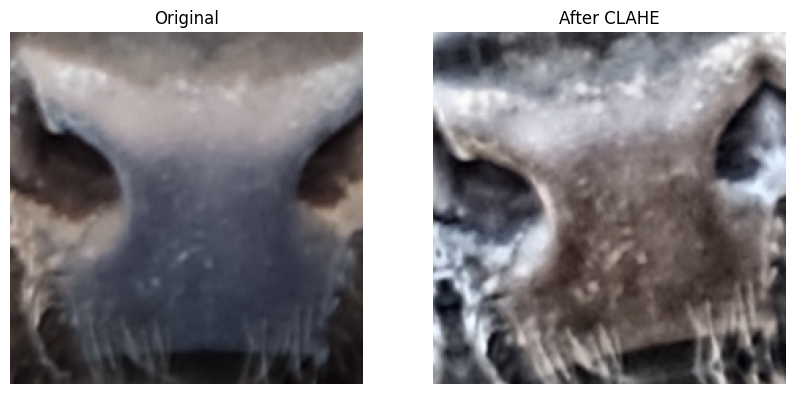

In [17]:
from torch.utils.data import DataLoader

train_dataset = ImageDataset(x_train, labels=y_train, augment=True)
validation_dataset = ImageDataset(x_val, labels=y_val, augment=False)
test_dataset = ImageDataset(x_test, labels = y_test, augment= False)

I1 = x_train[0]

if I1.ndim == 3 and I1.shape[0] == 3:
    I1 =  np.transpose(I1, (1, 2, 0))
if I1.dtype == np.float32 and I1.max() > 1.0:
    I1 = I1 / 255.0

I2, _ = train_dataset[0]


if I2.ndim == 3 and I2.shape[0] == 3:
    I2 = np.transpose(I2, (1, 2, 0))

if I2.dtype == np.float32 and I2.max() > 1.0:
    I2 = I2 / 255.0

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(I1, cmap=None)
axes[0].axis("off")
axes[0].set_title("Original")

axes[1].imshow(I2, cmap=None)
axes[1].axis("off")
axes[1].set_title("After CLAHE")
plt.savefig('BeforeAndAfter.jpg', dpi=150)
plt.show()


In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=False
)
val_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = True,
    num_workers = 2,
    pin_memory = False
)

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import math

**Define Arc Face **

In [20]:
class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50, easy_margin=False):
        super(ArcMarginProduct, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s  # scale
        self.m = m  # margin

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.easy_margin = easy_margin
        self.cos_m = torch.cos(torch.tensor(m))
        self.sin_m = torch.sin(torch.tensor(m))
        self.th = torch.cos(torch.tensor(3.14159265 - m))
        self.mm = torch.sin(torch.tensor(3.14159265 - m)) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m

        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)

        # Apply margin only to true class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

Training

**Define Resnet18 with arc face**

In [21]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

class ResNet18_FeatureExtractor(nn.Module):
    def __init__(self, num_classes, embedding_dim=256):
        super(ResNet18_FeatureExtractor, self).__init__()
        base_model = models.resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(base_model.children())[:-1])  # remove classifier head

        self.fc = nn.Sequential(
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )
        self.arc_margin = ArcMarginProduct(embedding_dim, num_classes)

    def forward(self, x, labels=None):
        x = self.backbone(x)        
        x = torch.flatten(x, 1)       
        features = self.fc(x)         

        if labels is not None:
            logits = self.arc_margin(features, labels)
            return features, logits   
        return features    

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(df_known)
model = ResNet18_FeatureExtractor(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


def train_one_epoch(loader, model, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        features, logits = model(images, labels)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

import torch
import numpy as np

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


Total parameters: 11,363,136
Trainable parameters: 11,363,136


In [23]:
def evaluate(loader, model, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    rank1_correct, rank5_correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            features, logits = model(images, labels)

            # Loss
            loss = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)

            # Softmax probabilities
            probs = torch.softmax(logits, dim=1)

            # Predicted class indices
            _, preds = torch.max(probs, 1)

            # Accuracy
            correct += (preds == labels).sum().item()
            top5_preds = torch.topk(probs, 5, dim=1).indices  # (N, 5)
            rank5_correct += top5_preds.eq(labels.view(-1, 1)).sum().item()
            total += labels.size(0)

            # Collect results
            all_preds.extend(preds.cpu().numpy())       # predicted class indices
            all_labels.extend(labels.cpu().numpy())     # ground truth labels
            all_probs.extend(probs.cpu().numpy())       # full softmax probabilities

    avg_loss = running_loss / total
    avg_acc = correct / total
    rank1_acc = correct / total
    rank5_acc = rank5_correct / total

    return avg_loss, avg_acc, np.array(all_preds), np.array(all_labels), np.array(all_probs), rank1_acc, rank5_acc

In [24]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
epochs = 20
import time

start_time = time.perf_counter()
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer, device)
    val_loss, val_acc, _, _, _, _, _ = evaluate(val_loader, model, criterion, device)
    scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time} seconds")

# Final test evaluation
test_loss, test_acc, test_preds, test_labels, test_prob, rank1_acc, rank5_acc = evaluate(test_loader, model, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
print(f"Rank1 accuracy: {rank1_acc}, Rank5 Accuracy: {rank5_acc}")

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds))

Epoch 1/20 | Train Acc: 0.0571 | Val Acc: 0.0168
Epoch 2/20 | Train Acc: 0.4142 | Val Acc: 0.3114
Epoch 3/20 | Train Acc: 0.7086 | Val Acc: 0.3519
Epoch 4/20 | Train Acc: 0.8534 | Val Acc: 0.5707
Epoch 5/20 | Train Acc: 0.9057 | Val Acc: 0.8586
Epoch 6/20 | Train Acc: 0.9382 | Val Acc: 0.1296
Epoch 7/20 | Train Acc: 0.9509 | Val Acc: 0.6364
Epoch 8/20 | Train Acc: 0.9541 | Val Acc: 0.8855
Epoch 9/20 | Train Acc: 0.9617 | Val Acc: 0.8620
Epoch 10/20 | Train Acc: 0.9733 | Val Acc: 0.9596
Epoch 11/20 | Train Acc: 0.9845 | Val Acc: 0.9798
Epoch 12/20 | Train Acc: 0.9852 | Val Acc: 0.9798
Epoch 13/20 | Train Acc: 0.9881 | Val Acc: 0.9781
Epoch 14/20 | Train Acc: 0.9902 | Val Acc: 0.9781
Epoch 15/20 | Train Acc: 0.9910 | Val Acc: 0.9815
Epoch 16/20 | Train Acc: 0.9888 | Val Acc: 0.9781
Epoch 17/20 | Train Acc: 0.9877 | Val Acc: 0.9781
Epoch 18/20 | Train Acc: 0.9906 | Val Acc: 0.9815
Epoch 19/20 | Train Acc: 0.9917 | Val Acc: 0.9798
Epoch 20/20 | Train Acc: 0.9899 | Val Acc: 0.9781
Execution

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
model.eval()
sample = next(iter(test_loader))[0][:1].to(device)  # one sample
start = time.time()
with torch.no_grad():
    features = model(sample)  # inference without labels
end = time.time()
print(f"Inference time per sample: {(end-start)*1000:.2f} ms")

Inference time per sample: 93.37 ms


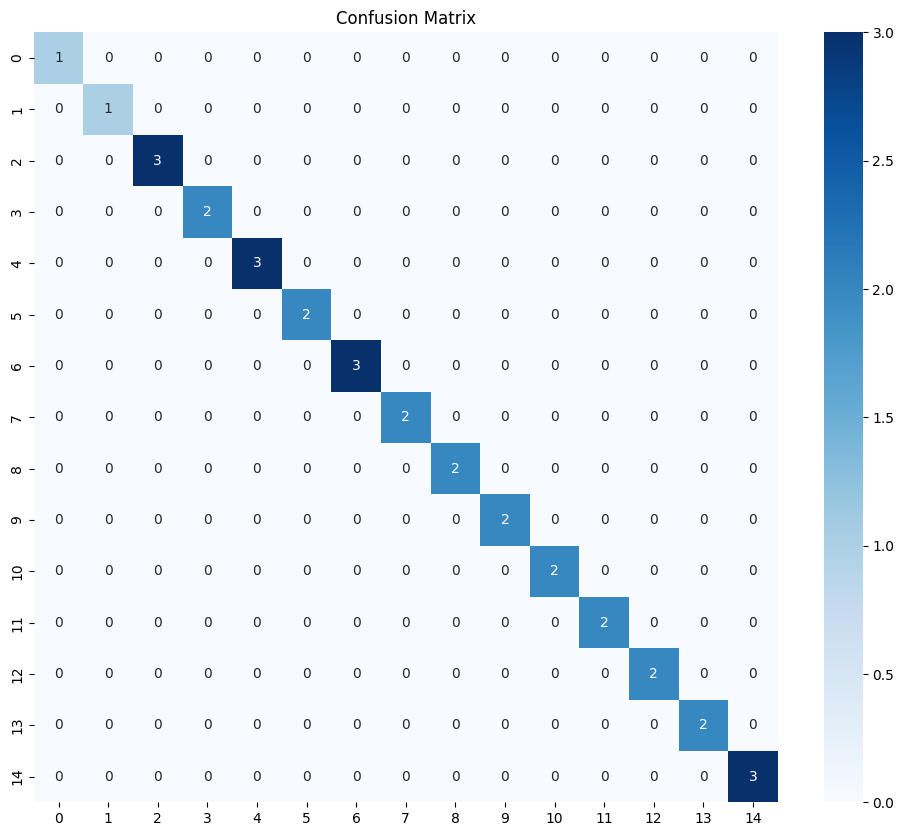

In [26]:
cm = confusion_matrix(test_labels, test_preds, labels= np.arange(15))
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.arange(15), yticklabels=np.arange(15))
plt.title("Confusion Matrix")
plt.savefig("ConfusionMatrix.jpg")
plt.show()




Text(0.5, 1.0, 'Training vs Validation Accuracy')

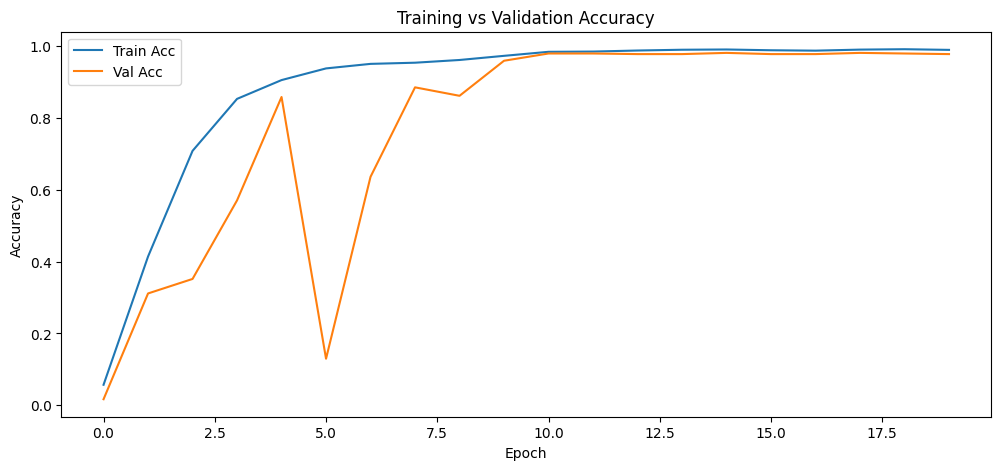

In [27]:
# 🔹 Accuracy & Loss curves
plt.figure(figsize=(12,5))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("Accuracy.jpg")
plt.title("Training vs Validation Accuracy")

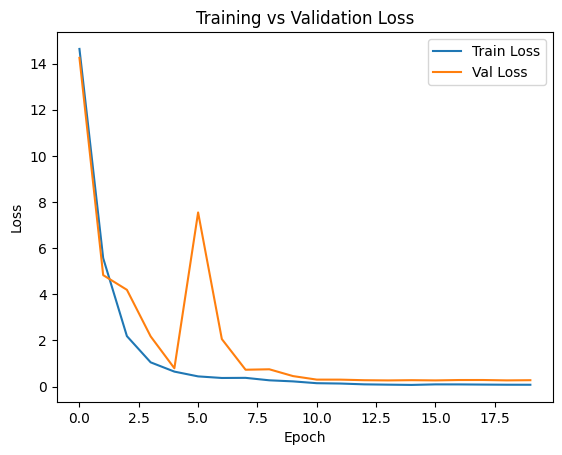

In [28]:

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("Loss.jpg")
plt.title("Training vs Validation Loss")
plt.show()

In [29]:
def get_probabilities_and_labels(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = model(images)  
            features = F.normalize(features)
            class_weights = F.normalize(model.arc_margin.weight) 
            cosine = F.linear(features, class_weights)  
            
            probs = F.softmax(cosine, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_probs), np.array(all_labels)

In [30]:
test_probs, test_labels = get_probabilities_and_labels(model, test_loader, device)
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    test_labels, 
    test_probs, 
    multi_class='ovr',   
    average='macro'    
)

print(f"ROC AUC score : {roc_auc:.4f}")


ROC AUC score : 1.0000


**Creating prototype gallery**

In [31]:

prototype_dataset = ImageDataset(x_train, labels=y_train, augment=False)
prototype_loader = DataLoader(
    prototype_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

def extract_features(loader, model, device):
    model.eval()
    features_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            feats = model(images)
            features_list.append(feats.cpu())
            labels_list.append(labels)
    features = torch.cat(features_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    return features, labels

train_features, train_labels = extract_features(prototype_loader, model, device)

# Global mean vector and L2-normalized mean
global_mean = train_features.mean(dim=0)
global_mean_norm = F.normalize(global_mean.unsqueeze(0), p=2, dim=1).squeeze(0)
print('Global feature mean shape:', global_mean_norm.shape)

prototype_gallery = {}
for label in torch.unique(train_labels):
    mask = train_labels == label
    class_features = train_features[mask]
    class_centroid = class_features.mean(dim=0)
    class_centroid_norm = F.normalize(class_centroid.unsqueeze(0), p=2, dim=1).squeeze(0)
    prototype_gallery[int(label.item())] = class_centroid_norm.cpu().numpy().astype(np.float32)

print(f'Created prototype gallery with {len(prototype_gallery)} entries.')

import pickle
with open('prototype_gallery.pkl', 'wb') as f:
    pickle.dump(prototype_gallery, f)

torch.save({
    'prototype_labels': np.array(sorted(prototype_gallery.keys()), dtype=np.int64),
    'prototype_vectors': torch.stack([torch.from_numpy(prototype_gallery[k]) for k in sorted(prototype_gallery.keys())])
}, 'prototype_gallery.pt') 

np.save('prototype_gallery_labels.npy', np.array(sorted(prototype_gallery.keys()), dtype=np.int64))
np.save('prototype_gallery_vectors.npy', np.stack([prototype_gallery[k] for k in sorted(prototype_gallery.keys())]))



Global feature mean shape: torch.Size([256])
Created prototype gallery with 214 entries.


**Test accuracy on prototype gallery**

In [32]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

def evaluate_with_prototypes(val_features, val_labels, proto_labels, proto_vectors):
    # Normalize features
    val_features_norm = F.normalize(val_features.to(device), p=2, dim=1)
    similarity_matrix = torch.matmul(val_features_norm, proto_vectors.T)  # [N, C]

    pred_indices = similarity_matrix.argmax(dim=1).cpu().numpy()
    pred_labels = proto_labels[pred_indices]
    acc = accuracy_score(val_labels.numpy(), pred_labels)

    prob_matrix = F.softmax(similarity_matrix, dim=1).cpu().numpy()
    val_labels_np = val_labels.numpy()

    return acc

In [33]:
test_features, test_labels = extract_features(test_loader, model, device)
proto_labels = np.array(sorted(prototype_gallery.keys()), dtype=np.int64)
proto_vectors = torch.stack([
    torch.from_numpy(prototype_gallery[k]) for k in proto_labels
]).to(device)

acc = evaluate_with_prototypes(test_features, test_labels, proto_labels, proto_vectors)
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9916


**Calcualate auc score for prototyping**

In [34]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score


device = proto_vectors.device
test_feats = test_features.to(device)  

proto_norm = F.normalize(proto_vectors, p=2, dim=1) 
feat_norm = F.normalize(test_feats, p=2, dim=1)      


sims = feat_norm @ proto_norm.T     
unique_proto_classes = np.unique(proto_labels)
class_to_proto_idx = {c: np.where(proto_labels == c)[0] for c in unique_proto_classes}

class_list = list(unique_proto_classes)
C_all = len(class_list)
N = sims.shape[0]
class_scores = torch.empty((N, C_all), device=device)

for i, c in enumerate(class_list):
    idxs = class_to_proto_idx[c]
    class_scores[:, i], _ = sims[:, idxs].max(dim=1)

present_classes = np.unique(test_labels)

present_mask = np.isin(class_list, present_classes)
present_idx_map = np.where(present_mask)[0]
filtered_scores = class_scores[:, present_idx_map] 
filtered_class_list = np.array(class_list)[present_idx_map]

probs = F.softmax(filtered_scores, dim=1).cpu().numpy()

label_to_index = {c: i for i, c in enumerate(filtered_class_list)}
y_true_idx = np.array([label_to_index[int(l)] for l in test_labels])
y_true_onehot = np.zeros_like(probs, dtype=int)
y_true_onehot[np.arange(len(y_true_idx)), y_true_idx] = 1

macro_auc = roc_auc_score(y_true_onehot, probs, multi_class='ovr', average='macro')
print(f"Evaluated Classes: {len(filtered_class_list)} out of {len(class_list)}")
print(f"AUC Score : {macro_auc:.4f}")


Evaluated Classes: 214 out of 214
AUC Score : 1.0000


**Global threshold tuning**

In [35]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import f1_score
val_features, val_labels = extract_features(val_loader, model, device)

val_features_norm = F.normalize(val_features, p=2, dim=1).to(device)
val_labels_np = val_labels.numpy()

checkpoint = torch.load('prototype_gallery.pt', map_location=device, weights_only=False)

prototype_vectors = checkpoint['prototype_vectors']
prototype_labels = checkpoint['prototype_labels']

if isinstance(prototype_vectors, np.ndarray):
    prototype_vectors = torch.from_numpy(prototype_vectors)
prototype_vectors = prototype_vectors.to(device, dtype=torch.float32)
val_features_norm = val_features_norm.to(device, dtype=torch.float32)
prototype_vectors = F.normalize(prototype_vectors, p=2, dim=1)

with torch.no_grad():
    sim_matrix = torch.matmul(val_features_norm, prototype_vectors.T)
    max_sims, pred_indices = torch.max(sim_matrix, dim=1)
    val_preds_np = prototype_labels[pred_indices.cpu().numpy()]
    val_sims_np = max_sims.cpu().numpy()

print(f"Cosine Matrix Range: Min = {val_sims_np.min():.4f} | Max = {val_sims_np.max():.4f}")
print(f"Base Accuracy: {(val_preds_np == val_labels_np).mean():.4f}")

best_threshold = -1.0
best_score = -1.0
unique_labels = np.unique(val_labels_np)

threshold_candidates = np.linspace(0.3,0.81, 50)

for t in threshold_candidates:
    tuned_preds = np.where(val_sims_np >= t, val_preds_np, -1)
    score = f1_score(
        val_labels_np,
        tuned_preds,
        labels=unique_labels, 
        average='macro',
        zero_division=0
    )
    
    if score >= best_score:
        best_score = score
        best_threshold = t


print(f"Optimal Global Cosine Threshold: {best_threshold:.4f}")
print(f"Maximized Validation Macro F1 Score: {best_score:.4f}")


Cosine Matrix Range: Min = 0.6282 | Max = 0.9977
Base Accuracy: 0.9899
Optimal Global Cosine Threshold: 0.6435
Maximized Validation Macro F1 Score: 0.9862


In [36]:
# Load Known and Unknown cattle datasets
known_df = pd.read_csv('KnownDataset.csv', index_col=0)
unknown_df = pd.read_csv('UnknownDataset.csv', index_col =0)

print("Known cattle IDs:", len(known_df))

Known cattle IDs: 214


In [37]:
# Extract features for known and unknown cattle
def get_cattle_features(df, model, device):
    features_dict = {}
    
    for idx, row in df.iterrows():
        cattle_id = row['Cattle_id']
        cattle_path = row['Path']
        
        cattle_features = []
        image_count = 0
        
        if os.path.isdir(cattle_path):
            for filename in sorted(os.listdir(cattle_path)):
                if filename.endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(cattle_path, filename)
                    try:
                        img = cv2.imread(img_path)
                        if img is None:
                            continue
                        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
                        y_channel, cr, cb = cv2.split(ycrcb)
                        y_channel = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(y_channel)
                        ycrcb_clahe = cv2.merge((y_channel, cr, cb))
                        img_rgb = cv2.cvtColor(ycrcb_clahe, cv2.COLOR_YCrCb2RGB)
                        img = cv2.resize(img_rgb, (224, 224))
                        img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
                        
                        with torch.no_grad():
                            feat = model(img_tensor)
                            cattle_features.append(feat.cpu().numpy())
                        image_count += 1
                        
                        if image_count >= 5:  # Limit to 5 images per cattle
                            break
                    except Exception as e:
                        print(f"Error processing {img_path}: {e}")
                        continue
        
        if cattle_features:
            avg_feature = np.mean(cattle_features, axis=0)
            features_dict[cattle_id] = avg_feature
    
    return features_dict

known_features = get_cattle_features(known_df, model, device)
print(f"Extracted features for {len(known_features)} known cattle")
unknown_features = get_cattle_features(unknown_df, model, device)
print(f"Extracted features for {len(unknown_features)} unknown cattle")

Extracted features for 214 known cattle
Extracted features for 54 unknown cattle


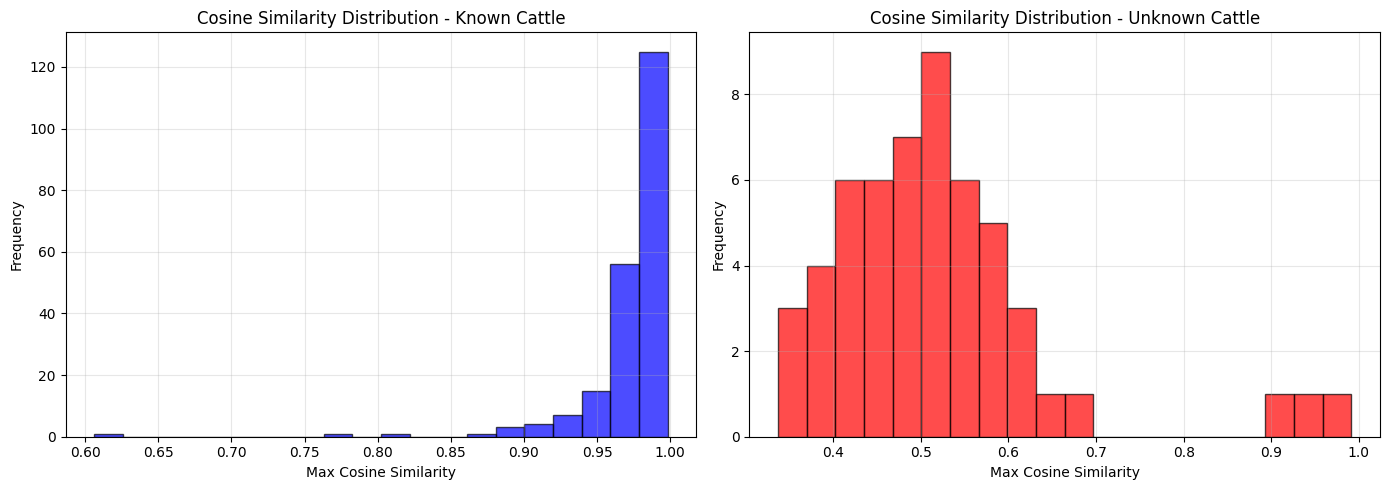


Known cattle - Mean max similarity: 0.9725 ± 0.0381
Unknown cattle - Mean max similarity: 0.5196 ± 0.1278


In [38]:
# Compute cosine similarity
from scipy.spatial.distance import cosine
from sklearn.metrics.pairwise import cosine_similarity

# Load prototype gallery
prototype_vectors = np.load('prototype_gallery_vectors.npy')
prototype_labels = np.load('prototype_gallery_labels.npy')

def compute_cosine_similarity(features_dict, prototype_vectors):
    similarities = {}
    
    for cattle_id, features in features_dict.items():
        features_norm = features / (np.linalg.norm(features) + 1e-8)
        
        sim = cosine_similarity(features_norm, prototype_vectors)[0]
        similarities[cattle_id] = sim
    
    return similarities

known_similarities = compute_cosine_similarity(known_features, prototype_vectors)
unknown_similarities = compute_cosine_similarity(unknown_features, prototype_vectors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Known cattle
known_max_sims = [max(sim) for sim in known_similarities.values()]
axes[0].hist(known_max_sims, bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Max Cosine Similarity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Cosine Similarity Distribution - Known Cattle')
axes[0].grid(True, alpha=0.3)

# Unknown cattle
unknown_max_sims = [max(sim) for sim in unknown_similarities.values()]
axes[1].hist(unknown_max_sims, bins=20, alpha=0.7, color='red', edgecolor='black')
axes[1].set_xlabel('Max Cosine Similarity')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Cosine Similarity Distribution - Unknown Cattle')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Cosine_Similarity_Distribution.jpg', dpi=150)
plt.show()
plt.close()

print(f"\nKnown cattle - Mean max similarity: {np.mean(known_max_sims):.4f} ± {np.std(known_max_sims):.4f}")
print(f"Unknown cattle - Mean max similarity: {np.mean(unknown_max_sims):.4f} ± {np.std(unknown_max_sims):.4f}")

ROC AUC Score: 0.9840
Optimal Threshold: 0.7711
TPR at Optimal Threshold: 0.9953
FPR at Optimal Threshold: 0.0556


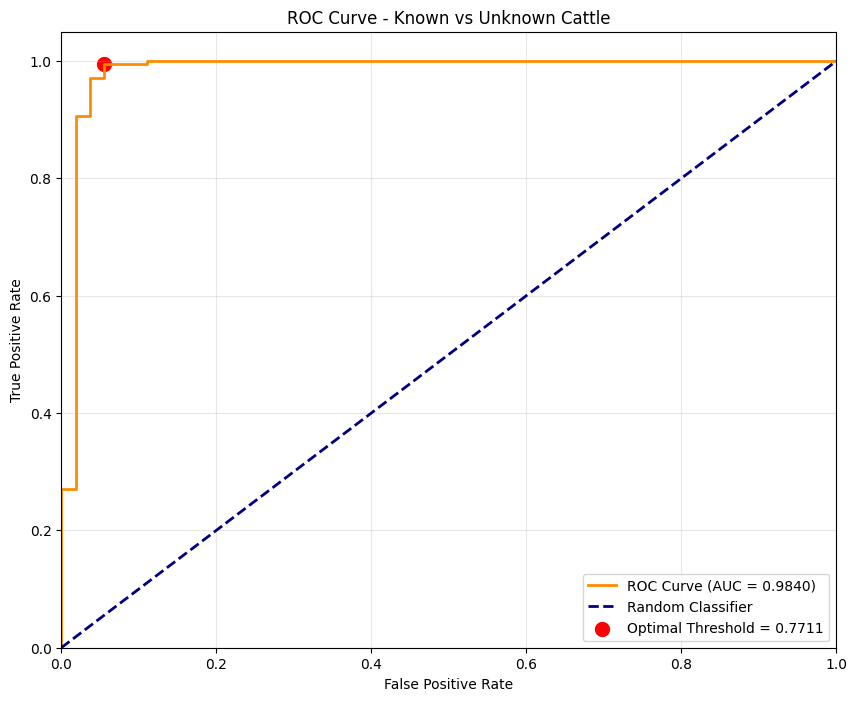

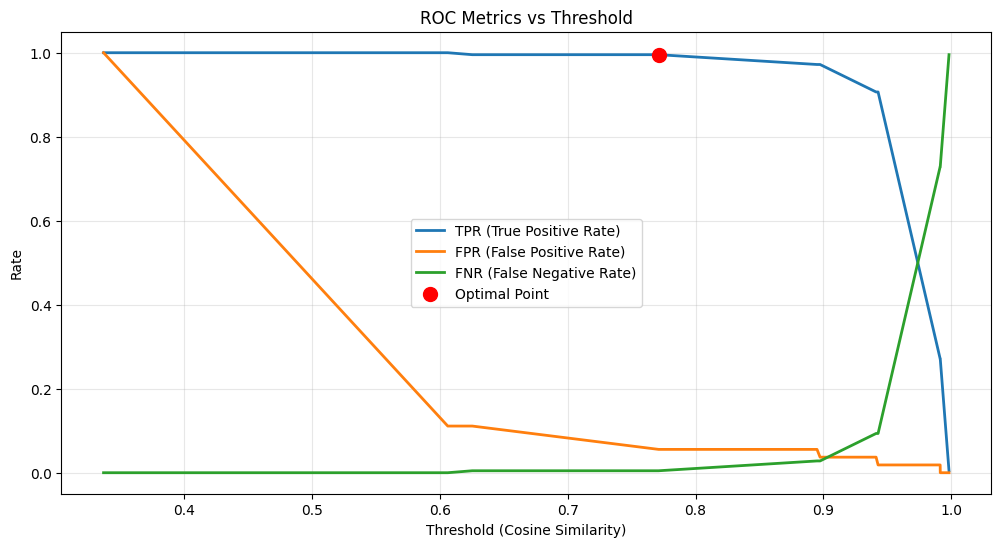

In [39]:
# ROC and AUC Analysis
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Label: 1 for known, 0 for unknown
known_scores = np.array(known_max_sims)
unknown_scores = np.array(unknown_max_sims)

y_true_roc = np.concatenate([np.ones(len(known_scores)), np.zeros(len(unknown_scores))])
y_scores_roc = np.concatenate([known_scores, unknown_scores])

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_roc, y_scores_roc)
roc_auc = auc(fpr, tpr)
j_scores = tpr - fpr
idx = np.argmax(j_scores)
optimal_threshold = thresholds[idx]
optimal_fpr = fpr[idx]
optimal_tpr = tpr[idx]

print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"TPR at Optimal Threshold: {optimal_tpr:.4f}")
print(f"FPR at Optimal Threshold: {optimal_fpr:.4f}")

# Plot ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.scatter(optimal_fpr, optimal_tpr, color='red', s=100, marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Known vs Unknown Cattle')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('ROC_Curve.jpg', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Plot threshold vs TPR/FPR
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, tpr, label='TPR (True Positive Rate)', linewidth=2)
ax.plot(thresholds, fpr, label='FPR (False Positive Rate)', linewidth=2)
ax.plot(thresholds, 1-tpr, label='FNR (False Negative Rate)', linewidth=2)
ax.scatter(optimal_threshold, optimal_tpr, color='red', s=100, marker='o', zorder=5, label=f'Optimal Point')

ax.set_xlabel('Threshold (Cosine Similarity)')
ax.set_ylabel('Rate')
ax.set_title('ROC Metrics vs Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('ROC_Metrics_vs_Threshold.jpg', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

**Test known dataset accuracy and unknown rejectioni rate**

Equal Error Rate (EER): 0.0349 at threshold 0.9000
FRR at EER: 0.0327
FAR at EER: 0.0370


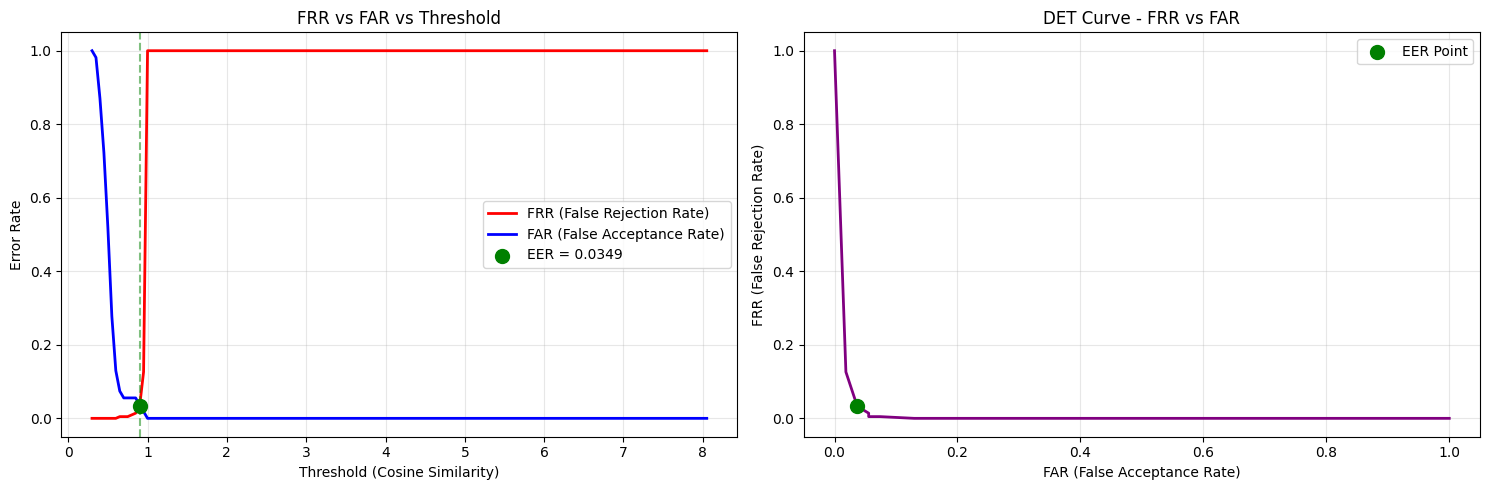

In [40]:
# FRR (False Rejection Rate) and FAR (False Acceptance Rate) Analysis
# FRR: Known samples rejected as unknown (1 - TPR)
# FAR: Unknown samples accepted as known (FPR)

thresholds_range = np.arange(0.3, 8.1, 0.05)
frr_list = []  
far_list = []  

for threshold in thresholds_range:
    known_rejected = np.sum(known_scores < threshold)
    known_accepted = len(known_scores) - known_rejected
    unknown_rejected = np.sum(unknown_scores < threshold)
    unknown_accepted = len(unknown_scores) - unknown_rejected
    
    # FRR: proportion of known samples that are rejected
    frr = known_rejected / len(known_scores) if len(known_scores) > 0 else 0
    
    # FAR: proportion of unknown samples that are accepted (false accept)
    far = unknown_accepted / len(unknown_scores) if len(unknown_scores) > 0 else 0
    
    frr_list.append(frr)
    far_list.append(far)

frr_list = np.array(frr_list)
far_list = np.array(far_list)

# Find Equal Error Rate (EER) - where FRR ≈ FAR
eer_idx = np.argmin(np.abs(frr_list - far_list))
eer_threshold = thresholds_range[eer_idx]
eer_value = (frr_list[eer_idx] + far_list[eer_idx]) / 2

print(f"Equal Error Rate (EER): {eer_value:.4f} at threshold {eer_threshold:.4f}")
print(f"FRR at EER: {frr_list[eer_idx]:.4f}")
print(f"FAR at EER: {far_list[eer_idx]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(thresholds_range, frr_list, label='FRR (False Rejection Rate)', linewidth=2, color='red')
axes[0].plot(thresholds_range, far_list, label='FAR (False Acceptance Rate)', linewidth=2, color='blue')
axes[0].scatter(eer_threshold, eer_value, color='green', s=100, marker='o', zorder=5, 
                label=f'EER = {eer_value:.4f}')
axes[0].axvline(eer_threshold, color='green', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold (Cosine Similarity)')
axes[0].set_ylabel('Error Rate')
axes[0].set_title('FRR vs FAR vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(far_list, frr_list, linewidth=2, color='purple')
axes[1].scatter(far_list[eer_idx], frr_list[eer_idx], color='green', s=100, marker='o', zorder=5,
                label=f'EER Point')
axes[1].set_xlabel('FAR (False Acceptance Rate)')
axes[1].set_ylabel('FRR (False Rejection Rate)')
axes[1].set_title('DET Curve - FRR vs FAR')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('FRR_FAR_Analysis.jpg', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [41]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  
        std=[0.229, 0.224, 0.225]
    )
])

class UnknownImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.image_paths = []
        self.labels = []
        unique_ids = df['Cattle_id'].unique()
        self.id_map = {cid: (idx+500) for idx, cid in enumerate(unique_ids)}

        # Flatten: store every image path with its cattle label
        for _, row in df.iterrows():
            folder = os.path.join(path, row['Path'])
            cattle_id = row['Cattle_id']
            label = self.id_map[cattle_id]
            for f in sorted(os.listdir(folder)):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(folder, f))
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

unknown_dataset = UnknownImageDataset(unknown_df, transform=img_transform)
unknown_loader = DataLoader(
    unknown_dataset,
    batch_size=1,   
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
known_dataset = ImageDataset(X, labels=y, augment=False)
known_loader = DataLoader(
    known_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)



In [42]:
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity

def extract_loader_embeddings(loader, model, device, expected_dim=None):
    model.eval()

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, (list, tuple)):
                images = batch[0]
                labels = batch[1] if len(batch) > 1 else None
            else:
                images = batch
                labels = None

            images = images.to(device)
            outputs = model(images)

            if isinstance(outputs, (tuple, list)):
                outputs = outputs[0]
            if isinstance(outputs, dict):
                outputs = next(iter(outputs.values()))

            embeddings = outputs.detach().cpu().numpy()

            if embeddings.ndim > 2:
                embeddings = embeddings.reshape(embeddings.shape[0], -1)
            elif embeddings.ndim == 1:
                embeddings = embeddings.reshape(1, -1)

            if expected_dim is not None and embeddings.shape[1] != expected_dim:
                raise ValueError(
                    f"Embedding dimension mismatch: got {embeddings.shape[1]}, "
                    f"expected {expected_dim}. Use the same model output used for prototype vectors."
                )

            all_embeddings.append(embeddings)

            if labels is not None:
                if torch.is_tensor(labels):
                    labels = labels.detach().cpu().numpy()
                all_labels.append(np.asarray(labels).reshape(-1))

    embeddings = np.vstack(all_embeddings)
    labels = np.concatenate(all_labels) if all_labels else None

    return embeddings, labels

In [43]:
import numpy as np

def as_feature_matrix(x, name="embeddings"):
    x = np.asarray(x, dtype=np.float32)

    if x.ndim == 1:
        x = x.reshape(1, -1)
    elif x.ndim > 2:
        x = x.reshape(x.shape[0], -1)

    if x.ndim != 2:
        raise ValueError(f"{name} must be 2D, got shape {x.shape}")

    return x


def as_label_vector(labels, name="labels"):
    labels = np.asarray(labels).reshape(-1)

    if len(labels) == 0:
        raise ValueError(f"{name} is empty")

    return labels


def l2_normalize(x):
    x = as_feature_matrix(x)
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-8)

In [44]:
def evaluate_global_threshold_from_loaders(known_loader,
                                           unknown_loader,
                                           model,
                                           prototype_vectors,
                                           prototype_labels,
                                           global_threshold,
                                           device=None):
    if device is None:
        device = next(model.parameters()).device

    prototype_vectors = as_feature_matrix(prototype_vectors, "prototype_vectors")
    prototype_labels = as_label_vector(prototype_labels, "prototype_labels")
    expected_dim = prototype_vectors.shape[1]

    known_embeddings, known_labels = extract_loader_embeddings(
        known_loader, model, device, expected_dim=expected_dim
    )

    unknown_embeddings, _ = extract_loader_embeddings(
        unknown_loader, model, device, expected_dim=expected_dim
    )

    prototype_vectors_norm = l2_normalize(prototype_vectors)

    known_sims = cosine_similarity(
        l2_normalize(known_embeddings),
        prototype_vectors_norm
    )

    known_best_idx = np.argmax(known_sims, axis=1)
    known_best_scores = known_sims[np.arange(len(known_embeddings)), known_best_idx]
    known_pred_labels = prototype_labels[known_best_idx]

    known_predicted_as_known = known_best_scores >= global_threshold

    known_correct = (
        known_predicted_as_known &
        (known_pred_labels == known_labels)
    )

    known_accuracy = known_correct.mean()

    unknown_sims = cosine_similarity(
        l2_normalize(unknown_embeddings),
        prototype_vectors_norm
    )

    unknown_best_scores = unknown_sims.max(axis=1)
    unknown_rejected = unknown_best_scores < global_threshold
    unknown_rejection_rate = unknown_rejected.mean()

    print(f"Global threshold: {global_threshold:.4f}")
    print(f"Known accuracy: {known_accuracy * 100:.2f}%")
    print(f"Unknown rejection rate: {unknown_rejection_rate * 100:.2f}%")

    return {
        "known_accuracy": known_accuracy,
        "unknown_rejection_rate": unknown_rejection_rate,
        "known_best_scores": known_best_scores,
        "known_pred_labels": known_pred_labels,
        "known_true_labels": known_labels,
        "unknown_best_scores": unknown_best_scores,
        "unknown_rejected": unknown_rejected,
    }

In [45]:
prototype_vectors = np.load("prototype_gallery_vectors.npy")
prototype_labels = np.load("prototype_gallery_labels.npy")

In [46]:
results = evaluate_global_threshold_from_loaders(
    known_loader,
    unknown_loader,
    model,
    prototype_vectors,
    prototype_labels,
    optimal_threshold
)

Global threshold: 0.7711
Known accuracy: 99.29%
Unknown rejection rate: 100.00%


**Grad Cam visualiztion**

In [47]:

import cv2
from torch.nn import functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hook to capture gradients and activations
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, class_idx=None):
        # Forward pass to get features
        self.model.eval()
        with torch.no_grad():
            output = self.model(input_tensor)
            # Handle both cases: features only or (features, logits)
            if isinstance(output, tuple):
                features, logits = output
            else:
                features = output
                logits = None
        
        # If we only have features, we need to compute logits
        if logits is None:
            # Create dummy labels to get logits
            batch_size = input_tensor.size(0)
            dummy_labels = torch.zeros(batch_size, dtype=torch.long, device=input_tensor.device)
            features_with_labels, logits = self.model(input_tensor, dummy_labels)
        
        # Get class index if not provided
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        
        # Backward pass
        target = logits[:, class_idx]
        self.model.zero_grad()
        target.backward()
        
        # Calculate Grad-CAM
        gradients = self.gradients[0]  # (C, H, W)
        activations = self.activations[0]  # (C, H, W)
        
        # Weighted combination of activation maps
        weights = gradients.mean(dim=(1, 2))  # (C,)
        cam = torch.zeros(activations.shape[1:], device=activations.device)
        
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        cam = F.relu(cam)
        cam = cam / (cam.max() + 1e-8)
        
        return cam.cpu().numpy(), class_idx


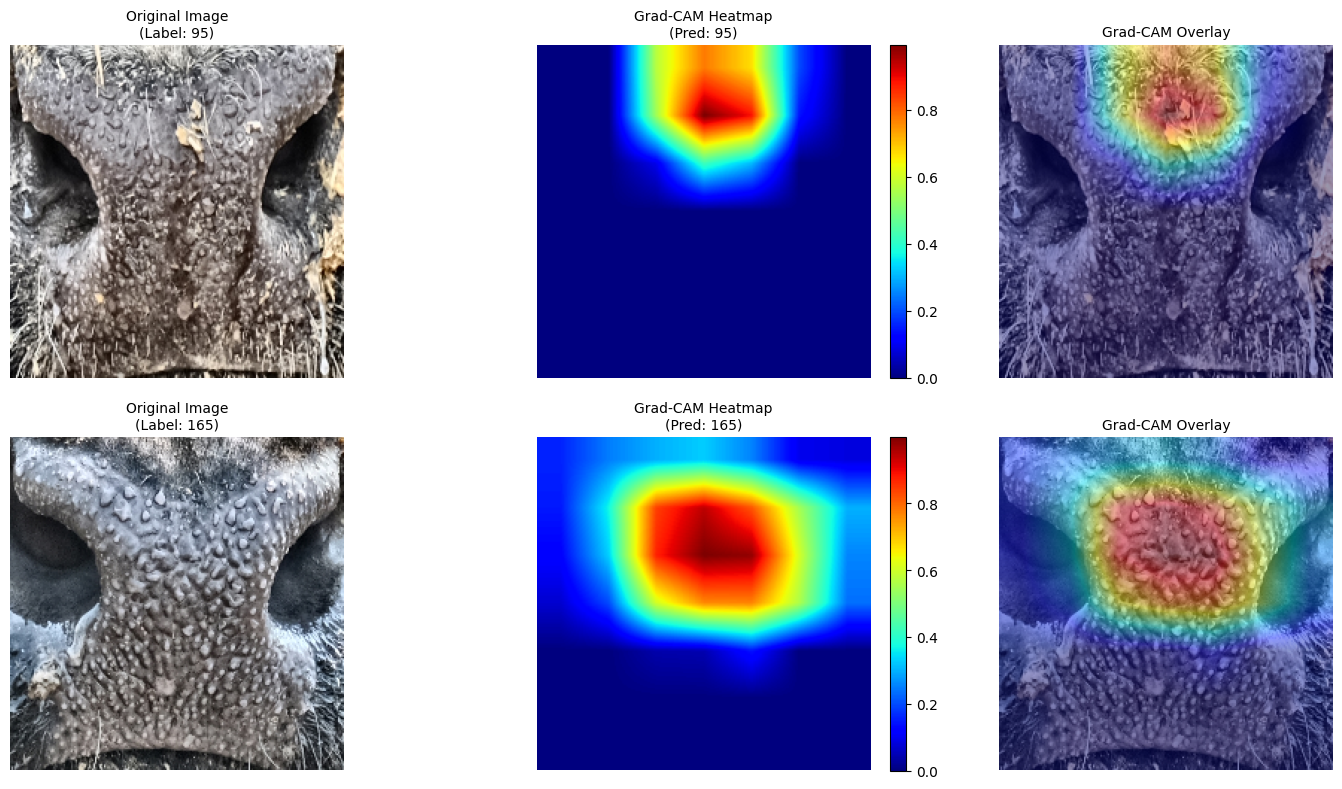

In [48]:

model.eval()
grad_cam = GradCAM(model, model.backbone[-2]) 

num_samples = 2
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))

for idx in range(num_samples):
    rand_idx = np.random.randint(0, len(test_dataset))
    img_tensor, label = test_dataset[rand_idx]
    
    img_batch = img_tensor.unsqueeze(0).to(device)
    
    cam, pred_class = grad_cam.generate_cam(img_batch, class_idx=int(label.item()))
    
    img_display = img_tensor.permute(1, 2, 0).cpu().numpy()
    cam_resized = cv2.resize(cam, (img_display.shape[1], img_display.shape[0]))
    
    # Create heatmap
    heatmap = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap / 255.0
    
    img_display = img_display.astype(np.float32)
    heatmap = heatmap.astype(np.float32)
    
    # Overlay heatmap on original image
    overlay = cv2.addWeighted(img_display, 0.6, heatmap, 0.4, 0)
    
    # Plot original image
    axes[idx, 0].imshow(img_display)
    axes[idx, 0].set_title(f'Original Image\n(Label: {label.item()})', fontsize=10)
    axes[idx, 0].axis('off')
    
    # Plot Grad-CAM heatmap
    im = axes[idx, 1].imshow(cam_resized, cmap='jet')
    axes[idx, 1].set_title(f'Grad-CAM Heatmap\n(Pred: {pred_class})', fontsize=10)
    axes[idx, 1].axis('off')
    plt.colorbar(im, ax=axes[idx, 1], fraction=0.046, pad=0.04)
    
    # Plot overlay
    axes[idx, 2].imshow(overlay)
    axes[idx, 2].set_title('Grad-CAM Overlay', fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig('GradCAM_Visualization.jpg', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**Check if model predicts unknown images correctly**

In [49]:
import torch
from torchvision import transforms
from sklearn.metrics.pairwise import cosine_similarity


random_idx = np.random.randint(0, len(unknown_df))
test_cattle_id = unknown_df.iloc[random_idx]['Cattle_id']
test_cattle_path = unknown_df.iloc[random_idx]['Path']
if os.path.isdir(test_cattle_path):
    all_images = [f for f in os.listdir(test_cattle_path) 
                  if f.endswith(('.jpg'))]
    if all_images:
        test_image_filename = all_images[np.random.randint(0, len(all_images))]
        test_image_path = os.path.join(test_cattle_path, test_image_filename)
        print(f"Selected image: {test_image_filename}")

test_image = cv2.imread(test_image_path)
if test_image is not None:
    test_image_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
    
    test_image_resized = cv2.resize(test_image_rgb, (224, 224))
    print(f"Image shape: {test_image_resized.shape}")
else:
    test_image_resized = None


if test_image_resized is not None:
    device = next(model.parameters()).device
    img_tensor = transforms.ToTensor()(test_image_resized).unsqueeze(0).to(device)
    
    with torch.no_grad():
        test_embedding = model(img_tensor).cpu().numpy().flatten()
similarities = []
for idx, gallery_vector in enumerate(prototype_vectors):
    sim = cosine_similarity(
        test_embedding.reshape(1, -1),
        gallery_vector.reshape(1, -1)
    )[0, 0]
    similarities.append(sim)

similarities = np.array(similarities)
max_sim_idx = np.argmax(similarities)
max_sim_value = similarities[max_sim_idx]

if max_sim_value >= optimal_threshold:
    print('known')
else:
    print('unknown')

Selected image: cattle_5165_DSCF7353.jpg
Image shape: (224, 224, 3)
known


**Few shot learning**

In [50]:
# import torch
# from torchvision import transforms
# prototype_vectors = np.load('prototype_gallery_vectors.npy')
# prototype_labels = np.load('prototype_gallery_labels.npy')

# print(f"Current gallery size: {len(prototype_labels)} cattle")
# print(f"Label range: {prototype_labels.min()} to {prototype_labels.max()}")


# unknown_df = pd.read_csv('UnknownDataset.csv', index_col=0)
# print(f"Total unknown cattle available: {len(unknown_df)}")

# unknown_cattle_idx = 10
# selected_cattle_id = unknown_df.iloc[unknown_cattle_idx]['Cattle_id']
# selected_cattle_path = unknown_df.iloc[unknown_cattle_idx]['Path']

# print(f"\nSelected cattle for registration: {selected_cattle_id}")
# print(f"Path: {selected_cattle_path}")


Current gallery size: 214 cattle
Label range: 0 to 213
Total unknown cattle available: 54

Selected cattle for registration: cattle_5604
Path: /kaggle/input/datasets/arunbailwal/beefcattlemuzzle/BeefCattle_Muzzle_Individualized/cattle_5604


**Few shots learning**

In [51]:
# few_shot_images = []
# image_files = []

# if os.path.isdir(selected_cattle_path):
#     all_files = [f for f in os.listdir(selected_cattle_path) 
#                  if f.endswith(('.jpg'))]
    
#     num_samples = min(4, len(all_files))
#     selected_files = all_files[:num_samples]
    
#     print(f"Found {len(all_files)} images, selecting {num_samples} for few-shot learning")
    
#     for filename in selected_files:
#         img_path = os.path.join(selected_cattle_path, filename)
#         img = cv2.imread(img_path)
#         if img is not None:
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#             ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
#             y_channel, cr, cb = cv2.split(ycrcb)
#             y_channel = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(y_channel)
#             ycrcb_clahe = cv2.merge((y_channel, cr, cb))
#             image_clahe = cv2.cvtColor(ycrcb_clahe, cv2.COLOR_YCrCb2RGB)
#             img_resized = cv2.resize(image_clahe, (224, 224))
#             few_shot_images.append(img_resized)
#             image_files.append(filename)
#             print(f"Loaded: {filename}")

Found 14 images, selecting 4 for few-shot learning
Loaded: cattle_5604_DSCF6927.jpg
Loaded: cattle_5604_DSCF6932.jpg
Loaded: cattle_5604_DSCF6926.jpg
Loaded: cattle_5604_DSCF6925.jpg


In [54]:
# device = next(model.parameters()).device  # Get device from model
# embeddings = []

# for idx, img in enumerate(few_shot_images):
#     try:
#         # Convert to tensor and normalize
#         img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
        
#         # Extract embedding using model
#         with torch.no_grad():
#             embedding = model(img_tensor)
        
#         # Convert to numpy and flatten
#         embedding_np = embedding.cpu().numpy().flatten()
#         embeddings.append(embedding_np)      
#     except Exception as e:
#         print(f"Error processing image {idx+1}: {e}")
#         continue

# print(f"\nTotal embeddings extracted: {len(embeddings)}")

# if len(embeddings) > 0:
#     embeddings = np.array(embeddings)
#     print(f"Embeddings array shape: {embeddings.shape}")



Total embeddings extracted: 4
Embeddings array shape: (4, 256)


**Test few shots learning on k examples for accuracy**

In [57]:
unknown_df = pd.read_csv('UnknownDataset.csv', index_col=0)
print(f"Total unknown cattle available: {len(unknown_df)}")

unknown_cattle_idx = 10
selected_cattle_id = unknown_df.iloc[unknown_cattle_idx]['Cattle_id']
selected_cattle_path = unknown_df.iloc[unknown_cattle_idx]['Path']

print(f"\nSelected cattle for registration: {selected_cattle_id}")
print(f"Path: {selected_cattle_path}")


Total unknown cattle available: 54

Selected cattle for registration: cattle_5604
Path: /kaggle/input/datasets/arunbailwal/beefcattlemuzzle/BeefCattle_Muzzle_Individualized/cattle_5604


In [59]:
class FewShotCattleGallery:
    def __init__(
        self,
        model,
        prototype_vectors,
        prototype_labels,
        image_size=(224, 224),
        transform=None,
        device=None
    ):
        self.model = model
        self.prototype_vectors = np.asarray(prototype_vectors)
        self.prototype_labels = np.asarray(prototype_labels)

        self.image_size = image_size
        self.device = device or next(model.parameters()).device

        self.transform = transform or transforms.ToTensor()

        self.model.eval()

    def l2_normalize(self, x, eps=1e-8):
        x = np.asarray(x)
        return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

    def load_image(self, image_path):
        img = cv2.imread(image_path)

        if img is None:
            return None

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
        y_channel, cr, cb = cv2.split(ycrcb)

        y_channel = cv2.createCLAHE(
            clipLimit=3.0,
            tileGridSize=(8, 8)
        ).apply(y_channel)

        ycrcb_clahe = cv2.merge((y_channel, cr, cb))
        img = cv2.cvtColor(ycrcb_clahe, cv2.COLOR_YCrCb2RGB)

        img = cv2.resize(img, self.image_size)

        return img

    def get_image_files(self, cattle_path):
        files = [
            f for f in os.listdir(cattle_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        files = sorted(files)

        return files

    def extract_embeddings_from_files(self, cattle_path, files):
        embeddings = []
        valid_files = []

        for filename in files:
            image_path = os.path.join(cattle_path, filename)
            img = self.load_image(image_path)

            if img is None:
                continue

            img_tensor = self.transform(img).unsqueeze(0).to(self.device)

            with torch.no_grad():
                embedding = self.model(img_tensor)

            embedding = embedding.cpu().numpy().flatten()

            embeddings.append(embedding)
            valid_files.append(filename)

        return np.asarray(embeddings), valid_files

    def make_mean_embedding(self, cattle_path, few_shot_count):
        all_files = self.get_image_files(cattle_path)

        few_shot_files = all_files[:few_shot_count]

        embeddings, valid_files = self.extract_embeddings_from_files(
            cattle_path,
            few_shot_files
        )

        if len(embeddings) == 0:
            raise ValueError("No valid few-shot images found.")

        mean_embedding = np.mean(embeddings, axis=0)

        return mean_embedding, embeddings, valid_files

    def update_temp_gallery(self, cattle_id, mean_embedding):
        cattle_id = int(cattle_id)

        keep_mask = self.prototype_labels != cattle_id

        temp_vectors = np.vstack([
            self.prototype_vectors[keep_mask],
            mean_embedding.reshape(1, -1)
        ])

        temp_labels = np.append(
            self.prototype_labels[keep_mask],
            cattle_id
        )

        return temp_vectors, temp_labels

    def evaluate_images(
        self,
        cattle_path,
        cattle_id,
        gallery_vectors,
        gallery_labels,
        exclude_files=None,
        threshold=None
    ):
        cattle_id = int(cattle_id)
        exclude_files = set(exclude_files or [])

        all_files = self.get_image_files(cattle_path)
        test_files = [f for f in all_files if f not in exclude_files]

        query_embeddings, valid_test_files = self.extract_embeddings_from_files(
            cattle_path,
            test_files
        )

        if len(query_embeddings) == 0:
            raise ValueError("No valid query/test images found.")

        query_labels = np.full(len(query_embeddings), cattle_id)

        similarities = cosine_similarity(
            self.l2_normalize(query_embeddings),
            self.l2_normalize(gallery_vectors)
        )

        top_indices = np.argmax(similarities, axis=1)
        top_scores = np.max(similarities, axis=1)
        predictions = gallery_labels[top_indices]

        total_accuracy = accuracy_score(query_labels, predictions)

        result = {
            "cattle_id": cattle_id,
            "num_test_images": len(valid_test_files),
            "test_files": valid_test_files,
            "predictions": predictions,
            "top_scores": top_scores,
            "accuracy": total_accuracy
        }

        if threshold is not None:
            accepted_mask = top_scores >= threshold

            accepted_true = query_labels[accepted_mask]
            accepted_pred = predictions[accepted_mask]

            accepted_accuracy = (
                accuracy_score(accepted_true, accepted_pred)
                if len(accepted_true) > 0 else 0
            )

            result.update({
                "threshold": threshold,
                "accepted": int(np.sum(accepted_mask)),
                "rejected": int(np.sum(~accepted_mask)),
                "accepted_accuracy": accepted_accuracy
            })

        return result

    def run_for_k(
        self,
        cattle_id,
        cattle_path,
        few_shot_count,
        threshold=None,
        exclude_fewshot_from_test=True
    ):
        mean_embedding, fewshot_embeddings, fewshot_files = self.make_mean_embedding(
            cattle_path,
            few_shot_count
        )

        temp_vectors, temp_labels = self.update_temp_gallery(
            cattle_id,
            mean_embedding
        )

        exclude_files = fewshot_files if exclude_fewshot_from_test else None

        eval_result = self.evaluate_images(
            cattle_path=cattle_path,
            cattle_id=cattle_id,
            gallery_vectors=temp_vectors,
            gallery_labels=temp_labels,
            exclude_files=exclude_files,
            threshold=threshold
        )

        print(f"\nCattle ID: {cattle_id}")
        print(f"Few-shot count: {few_shot_count}")
        print(f"Few-shot files: {fewshot_files}")
        print(f"Test images: {eval_result['num_test_images']}")
        print(f"Accuracy: {eval_result['accuracy'] * 100:.2f}%")
        print(f"Mean top score: {np.mean(eval_result['top_scores']):.4f}")

        if threshold is not None:
            print(f"Threshold: {threshold}")
            print(f"Accepted: {eval_result['accepted']}")
            print(f"Rejected: {eval_result['rejected']}")
            print(f"Accepted accuracy: {eval_result['accepted_accuracy'] * 100:.2f}%")

        return {
            "cattle_id": cattle_id,
            "few_shot_count": few_shot_count,
            "fewshot_files": fewshot_files,
            "fewshot_embeddings": fewshot_embeddings,
            "mean_embedding": mean_embedding,
            "temp_prototype_vectors": temp_vectors,
            "temp_prototype_labels": temp_labels,
            "evaluation": eval_result
        }

    def run_multiple_k(
        self,
        cattle_id,
        cattle_path,
        few_shot_counts,
        threshold=None,
        exclude_fewshot_from_test=True
    ):
        results = {}

        for k in few_shot_counts:
            results[k] = self.run_for_k(
                cattle_id=cattle_id,
                cattle_path=cattle_path,
                few_shot_count=k,
                threshold=threshold,
                exclude_fewshot_from_test=exclude_fewshot_from_test
            )

        return results

    def permanently_update_gallery(self, cattle_id, mean_embedding):
        cattle_id = int(cattle_id)

        keep_mask = self.prototype_labels != cattle_id

        self.prototype_vectors = np.vstack([
            self.prototype_vectors[keep_mask],
            mean_embedding.reshape(1, -1)
        ])

        self.prototype_labels = np.append(
            self.prototype_labels[keep_mask],
            cattle_id
        )

        print(f"Gallery updated for cattle ID: {cattle_id}")
        print(f"New gallery size: {len(self.prototype_labels)}")

        return self.prototype_vectors, self.prototype_labels

In [60]:
fewshot_gallery = FewShotCattleGallery(
    model=model,
    prototype_vectors=prototype_vectors,
    prototype_labels=prototype_labels
)

results = fewshot_gallery.run_multiple_k(
    cattle_id=214,
    cattle_path=selected_cattle_path,
    few_shot_counts=[1, 3, 5, 10],
    threshold=optimal_threshold,
    exclude_fewshot_from_test=False
)


Cattle ID: 214
Few-shot count: 1
Few-shot files: ['cattle_5604_DSCF6925.jpg']
Test images: 14
Accuracy: 57.14%
Mean top score: 0.6295
Threshold: 0.7711359262466431
Accepted: 2
Rejected: 12
Accepted accuracy: 100.00%

Cattle ID: 214
Few-shot count: 3
Few-shot files: ['cattle_5604_DSCF6925.jpg', 'cattle_5604_DSCF6926.jpg', 'cattle_5604_DSCF6927.jpg']
Test images: 14
Accuracy: 78.57%
Mean top score: 0.6742
Threshold: 0.7711359262466431
Accepted: 4
Rejected: 10
Accepted accuracy: 100.00%

Cattle ID: 214
Few-shot count: 5
Few-shot files: ['cattle_5604_DSCF6925.jpg', 'cattle_5604_DSCF6926.jpg', 'cattle_5604_DSCF6927.jpg', 'cattle_5604_DSCF6928.jpg', 'cattle_5604_DSCF6929.jpg']
Test images: 14
Accuracy: 85.71%
Mean top score: 0.6845
Threshold: 0.7711359262466431
Accepted: 5
Rejected: 9
Accepted accuracy: 100.00%

Cattle ID: 214
Few-shot count: 10
Few-shot files: ['cattle_5604_DSCF6925.jpg', 'cattle_5604_DSCF6926.jpg', 'cattle_5604_DSCF6927.jpg', 'cattle_5604_DSCF6928.jpg', 'cattle_5604_DSCF6

In [61]:
best_k = 5
best_mean_embedding = results[best_k]["mean_embedding"]

updated_vectors, updated_labels = fewshot_gallery.permanently_update_gallery(
    cattle_id=214,
    mean_embedding=best_mean_embedding
)

Gallery updated for cattle ID: 214
New gallery size: 215


In [62]:
np.save("prototype_gallery_vectors_updated.npy", updated_vectors)
np.save("prototype_gallery_labels_updated.npy", updated_labels)

torch.save({
    "prototype_vectors": torch.from_numpy(updated_vectors),
    "prototype_labels": updated_labels
}, "prototype_gallery_updated.pt")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 214 samples in 0.000s...
[t-SNE] Computed neighbors for 214 samples in 0.056s...
[t-SNE] Computed conditional probabilities for sample 214 / 214
[t-SNE] Mean sigma: 0.314565
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.974060
[t-SNE] KL divergence after 1000 iterations: 1.443385


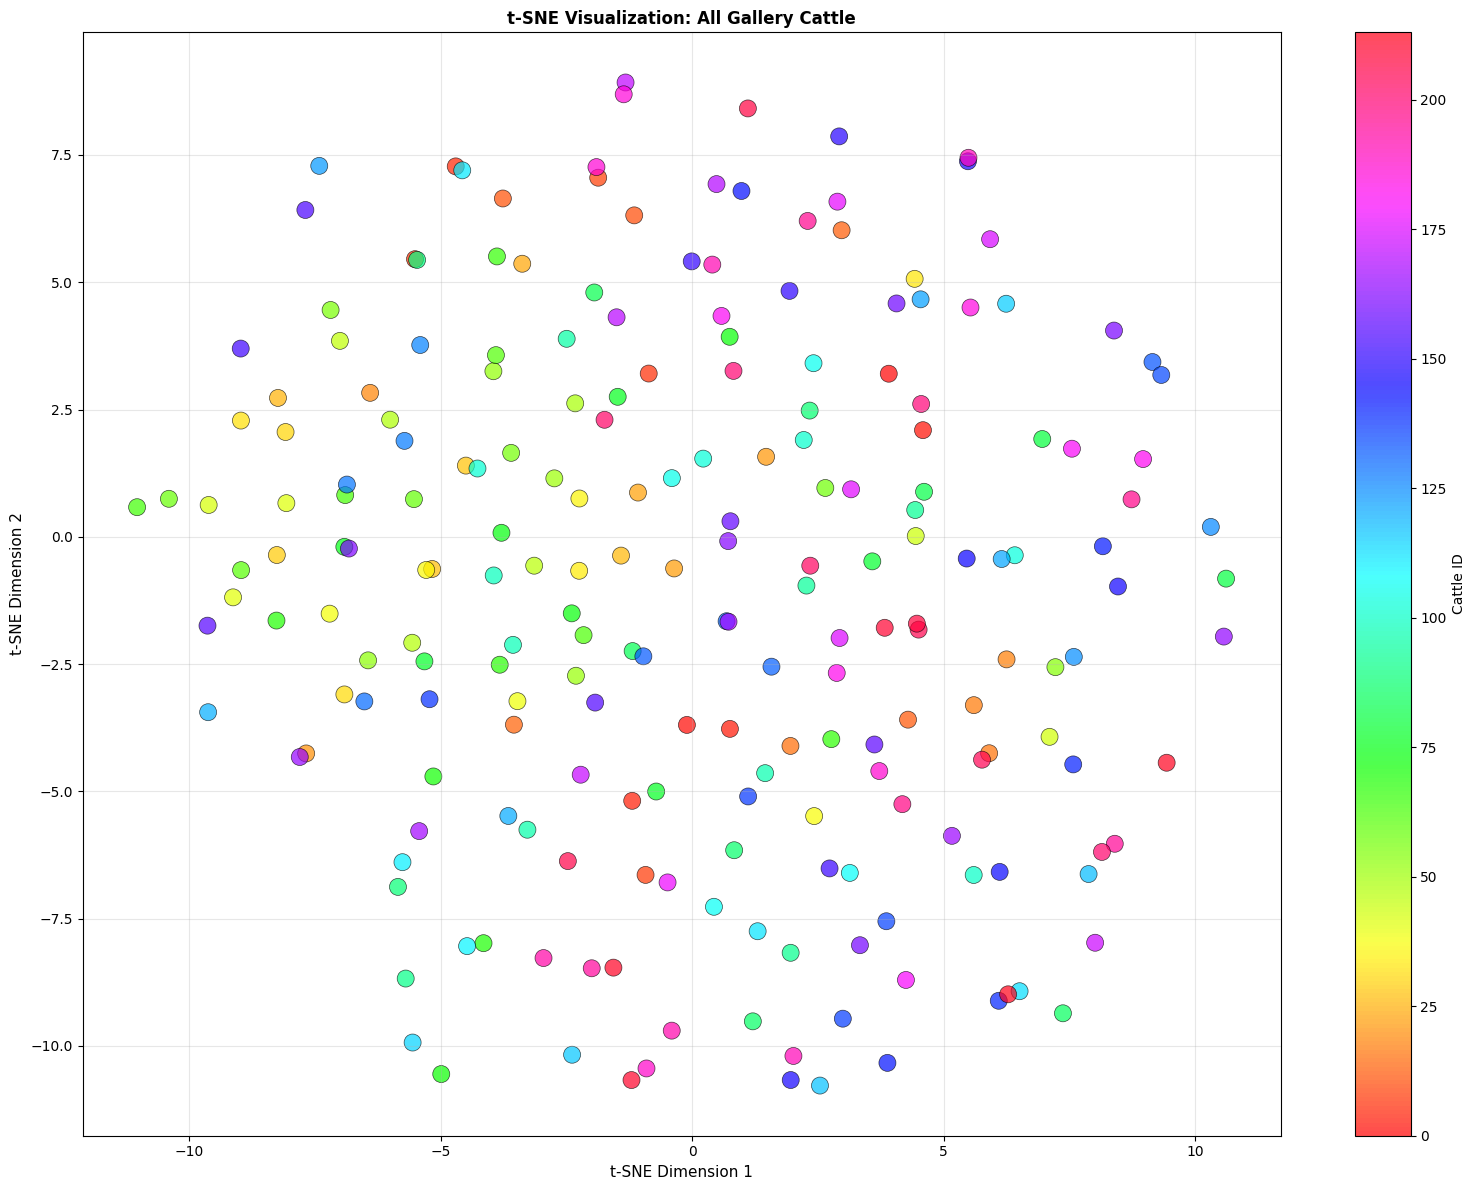

In [63]:
import seaborn as sns
from sklearn.manifold import TSNE
prototype_vectors = np.load('prototype_gallery_vectors.npy')
prototype_labels = np.load('prototype_gallery_labels.npy')
tsne = TSNE(n_components=2, 
            perplexity=30,
            n_iter=1000,
            random_state=42,
            n_jobs=-1,
            verbose=1)

tsne_results = tsne.fit_transform(prototype_vectors)
fig = plt.figure(figsize=(16, 12))
ax1 = plt.subplot(1, 1, 1)
scatter = ax1.scatter(tsne_results[:, 0], tsne_results[:, 1], 
                      c=prototype_labels, 
                      cmap='tab20' if len(prototype_labels) <= 20 else 'hsv',
                      s=150,
                      alpha=0.7,
                      edgecolors='black',
                      linewidth=0.5)
ax1.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax1.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax1.set_title('t-SNE Visualization: All Gallery Cattle', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Cattle ID', fontsize=10)
plt.tight_layout()
plt.savefig('tsne_visualization_advanced.jpg', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
